In [1]:
DATA_PATH = "/home/jovyan/projects/time_series_notebook/data_raw/merged_long_df.csv"
DATE_COL = "Datetime"
TARGET = "MW"
SERIES_ID_COL = "region"   # your grouping column (12 regions) -- NOT None
FORECAST_HORIZON = 30
N_TEST_PERIODS = 30
EXOG_COLS = []              # known future exogenous variables, like holidays
RANDOM_STATE = 42
FREQ = "h"                  # pandas frequency string, e.g. "h" hourly, "d" daily, "w" weekly
MAX_TRAIN_POINTS = 17520    # per-region cap for classical/DL models (2 years hourly)
N_SPLITS = 3                 # walk-forward CV folds. Keep small: 12 regions x many folds = many model fits.


In [2]:
# One-time setup. Safe to skip after the first run (pip no-ops if already installed).
import subprocess, sys
for pkg in ["numpy", "pandas", "matplotlib", "seaborn", "statsmodels",
            "pmdarima", "prophet", "scikit-learn", "xgboost", "lightgbm", "tensorflow"]:
    subprocess.run([sys.executable, "-m", "pip", "install", "-q", pkg])
print("Packages ready.")


Packages ready.


In [3]:
import os
os.environ["CUDA_VISIBLE_DEVICES"] = "-1"   # force CPU -- see note above; delete to allow GPU

import numpy as np
import pandas as pd
import warnings
warnings.filterwarnings("ignore")
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (11, 4)

# Stats / classical time series
from statsmodels.tsa.seasonal import seasonal_decompose, STL
from statsmodels.tsa.stattools import adfuller, kpss
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.holtwinters import ExponentialSmoothing
from statsmodels.tsa.statespace.sarimax import SARIMAX

try:
    from pmdarima import auto_arima
    HAVE_PMDARIMA = True   # FIX: this was hardcoded to False before, so auto_arima never ran
except ImportError:
    HAVE_PMDARIMA = False
    print("pmdarima not installed \u2014 auto_arima cell will be skipped")

try:
    from prophet import Prophet
    HAVE_PROPHET = True
except ImportError:
    HAVE_PROPHET = False
    print("prophet not installed \u2014 Prophet cell will be skipped")

# ML on engineered features
from sklearn.model_selection import TimeSeriesSplit
from sklearn.ensemble import RandomForestRegressor
from sklearn.preprocessing import StandardScaler
import xgboost as xgb
import lightgbm as lgb

# Optional deep learning
try:
    import tensorflow as tf
    from tensorflow.keras.models import Sequential
    from tensorflow.keras.layers import LSTM, Dense
    from tensorflow.keras.callbacks import EarlyStopping
    HAVE_TENSORFLOW = True
except ImportError:
    HAVE_TENSORFLOW = False
    print("tensorflow not installed \u2014 LSTM cell will be skipped")

# Metrics
from sklearn.metrics import mean_absolute_error, mean_squared_error

def smape(y_true, y_pred):
    y_true, y_pred = np.asarray(y_true, dtype=float), np.asarray(y_pred, dtype=float)
    denom = np.abs(y_true) + np.abs(y_pred)
    denom[denom == 0] = 1e-9
    return 200 * np.mean(np.abs(y_pred - y_true) / denom)

def mape(y_true, y_pred):
    y_true, y_pred = np.asarray(y_true, dtype=float), np.asarray(y_pred, dtype=float)
    mask = y_true != 0
    return 100 * np.mean(np.abs((y_true[mask] - y_pred[mask]) / y_true[mask]))


I0000 00:00:1787599935.219010     271 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
I0000 00:00:1787599935.260861     271 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


I0000 00:00:1787599936.549826     271 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.


In [4]:
df = pd.read_csv(DATA_PATH, parse_dates=[DATE_COL])
print(f"Data shape: {df.shape}")
df.head()

Data shape: (1090127, 30)


,Datetime,region,MW,hour,day_of_week,month,quarter,year,is_weekend,hour_sin,...,load_roll_std_24h,load_roll_mean_168h,is_holiday,is_month_start,is_month_end,load_roll_std_168h,fourier_sin_1,fourier_cos_1,fourier_sin_2,fourier_cos_2
0,2004-10-01 01:00:00,AEP,12379.0,1,4,10,4,2004,0,0.258819,...,NaN,NaN,0,1,0,NaN,0.000000,1.000000,0.000000,1.000000e+00
1,2004-10-01 02:00:00,AEP,11935.0,2,4,10,4,2004,0,0.500000,...,NaN,NaN,0,1,0,NaN,0.258819,0.965926,0.500000,8.660254e-01
2,2004-10-01 03:00:00,AEP,11692.0,3,4,10,4,2004,0,0.707107,...,NaN,NaN,0,1,0,NaN,0.500000,0.866025,0.866025,5.000000e-01
3,2004-10-01 04:00:00,AEP,11597.0,4,4,10,4,2004,0,0.866025,...,NaN,NaN,0,1,0,NaN,0.707107,0.707107,1.000000,6.123234e-17
4,2004-10-01 05:00:00,AEP,11681.0,5,4,10,4,2004,0,0.965926,...,NaN,NaN,0,1,0,NaN,0.866025,0.500000,0.866025,-5.000000e-01


In [5]:
# the date range

print(f"Date range: {df[DATE_COL].min()} to {df[DATE_COL].max()}")

Date range: 1998-04-01 01:00:00 to 2018-08-03 00:00:00


In [6]:
sample = df if not SERIES_ID_COL else df[df[SERIES_ID_COL] == df[SERIES_ID_COL].iloc[0]]
inferred = pd.infer_freq(sample[DATE_COL])
print(f"FREQ set to {FREQ!r} | pandas-inferred: {inferred!r}")
if FREQ is None:
    FREQ = inferred
print(f"FREQ was None -> using inferred value: {FREQ!r}")

FREQ set to 'h' | pandas-inferred: None
FREQ was None -> using inferred value: 'h'


In [7]:
full_range = pd.date_range(sample[DATE_COL].min(), sample[DATE_COL].max(), freq=FREQ)
n_gaps = len(full_range) - sample[DATE_COL].nunique()
print(f"Expected {len(full_range)} timestamps at freq={FREQ!r}, found {sample[DATE_COL].nunique()} -> {n_gaps} missing")

Expected 121296 timestamps at freq='h', found 121269 -> 27 missing


In [8]:
full_range = pd.date_range(sample[DATE_COL].min(), sample[DATE_COL].max(), freq='h')
missing_times = full_range.difference(sample[DATE_COL])
print(missing_times)

DatetimeIndex(['2004-10-31 02:00:00', '2005-04-03 03:00:00',
               '2005-10-30 02:00:00', '2006-04-02 03:00:00',
               '2006-10-29 02:00:00', '2007-03-11 03:00:00',
               '2007-11-04 02:00:00', '2008-03-09 03:00:00',
               '2008-11-02 02:00:00', '2009-03-08 03:00:00',
               '2009-11-01 02:00:00', '2010-03-14 03:00:00',
               '2010-11-07 02:00:00', '2010-12-10 00:00:00',
               '2011-03-13 03:00:00', '2011-11-06 02:00:00',
               '2012-03-11 03:00:00', '2012-11-04 02:00:00',
               '2012-12-06 04:00:00', '2013-03-10 03:00:00',
               '2013-11-03 02:00:00', '2014-03-09 03:00:00',
               '2014-03-11 14:00:00', '2015-03-08 03:00:00',
               '2016-03-13 03:00:00', '2017-03-12 03:00:00',
               '2018-03-11 03:00:00'],
              dtype='datetime64[ns]', freq=None)


In [9]:
# Handle any remaining missing timestamps after the dedup + reindex
# done upstream in book1. Duplicate labels happen if the CSV still
# contains repeated timestamps, so drop them first, then reindex to
# the full hourly grid and fill genuinely-missing loads by linear
# interpolation over time (safe for a single 2010-12-10 gap).
sample = df if not SERIES_ID_COL else df[df[SERIES_ID_COL] == df[SERIES_ID_COL].iloc[0]]
sample = sample.drop_duplicates(subset=DATE_COL)
sample = sample.set_index(DATE_COL)
full_range = pd.date_range(sample.index.min(), sample.index.max(), freq="h")
sample = sample.reindex(full_range)
sample["MW"] = sample["MW"].interpolate(method="time", limit_direction="both")
sample = sample.reset_index().rename(columns={"index": DATE_COL})
sample.head()

,Datetime,region,MW,hour,day_of_week,month,quarter,year,is_weekend,hour_sin,...,load_roll_std_24h,load_roll_mean_168h,is_holiday,is_month_start,is_month_end,load_roll_std_168h,fourier_sin_1,fourier_cos_1,fourier_sin_2,fourier_cos_2
0,2004-10-01 01:00:00,AEP,12379.0,1.0,4.0,10.0,4.0,2004.0,0.0,0.258819,...,NaN,NaN,0.0,1.0,0.0,NaN,0.000000,1.000000,0.000000,1.000000e+00
1,2004-10-01 02:00:00,AEP,11935.0,2.0,4.0,10.0,4.0,2004.0,0.0,0.500000,...,NaN,NaN,0.0,1.0,0.0,NaN,0.258819,0.965926,0.500000,8.660254e-01
2,2004-10-01 03:00:00,AEP,11692.0,3.0,4.0,10.0,4.0,2004.0,0.0,0.707107,...,NaN,NaN,0.0,1.0,0.0,NaN,0.500000,0.866025,0.866025,5.000000e-01
3,2004-10-01 04:00:00,AEP,11597.0,4.0,4.0,10.0,4.0,2004.0,0.0,0.866025,...,NaN,NaN,0.0,1.0,0.0,NaN,0.707107,0.707107,1.000000,6.123234e-17
4,2004-10-01 05:00:00,AEP,11681.0,5.0,4.0,10.0,4.0,2004.0,0.0,0.965926,...,NaN,NaN,0.0,1.0,0.0,NaN,0.866025,0.500000,0.866025,-5.000000e-01


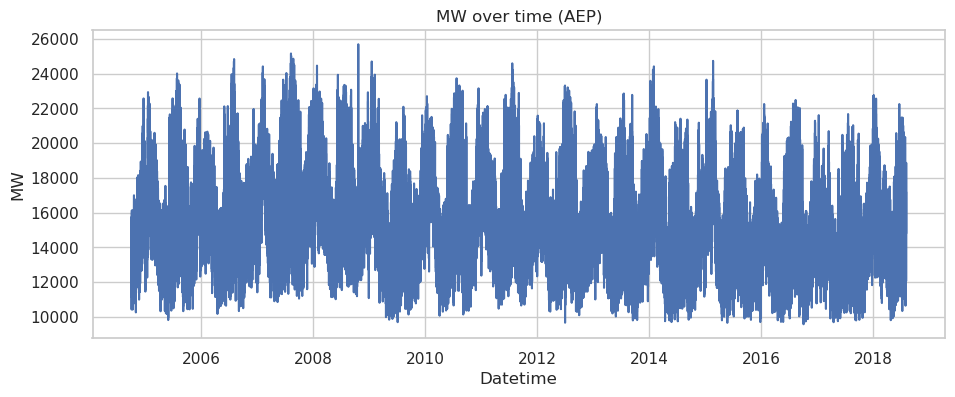

In [10]:
plot_df = df if not SERIES_ID_COL else df[df[SERIES_ID_COL] == df[SERIES_ID_COL].iloc[0]]
plt.plot(plot_df[DATE_COL], plot_df[TARGET])
title_suffix = f" ({df[SERIES_ID_COL].iloc[0]})" if SERIES_ID_COL else ""
plt.title(f"{TARGET} over time{title_suffix}")
plt.xlabel(DATE_COL); plt.ylabel(TARGET)
plt.show()

In [11]:
# ACTION: duplicate timestamps (same date, same series) must be resolved before
# reindexing -- most models assume exactly one value per period.
group_cols = ([SERIES_ID_COL] if SERIES_ID_COL else []) + [DATE_COL]
dupes = df.duplicated(subset=group_cols).sum()
print(f"Duplicate (series, timestamp) pairs: {dupes}")
if dupes:
    # DECISION: aggregate (sum for counts/sales, mean for rates/prices) rather than
    # blindly dropping -- pick the aggregation that matches what TARGET represents.
    other_cols = [c for c in df.columns if c not in group_cols + [TARGET]]
    agg = {TARGET: "sum", **{c: "first" for c in other_cols}}
    df = df.groupby(group_cols, as_index=False).agg(agg)
    print(f"Aggregated down to {len(df)} rows.")

Duplicate (series, timestamp) pairs: 0


In [12]:
# ACTION: reindex each series onto a complete, regularly-spaced date range at FREQ.
# WHY: this turns "irregular gaps" into explicit NaNs you can see and decide how to
# handle, instead of silently letting models assume evenly-spaced data that isn't.
def reindex_series(g):
    full_idx = pd.date_range(g[DATE_COL].min(), g[DATE_COL].max(), freq=FREQ)
    g = g.set_index(DATE_COL).reindex(full_idx)
    g.index.name = DATE_COL
    return g

if SERIES_ID_COL:
    df = (df.groupby(SERIES_ID_COL, group_keys=False)
            .apply(reindex_series)
            .reset_index())
else:
    df = reindex_series(df).reset_index()

n_missing_after = df[TARGET].isna().sum()
print(f"Rows after reindexing to a full {FREQ} grid: {len(df)} | missing {TARGET} values to fill: {n_missing_after}")
     

Rows after reindexing to a full h grid: 1090344 | missing MW values to fill: 217


In [13]:
# ACTION: rolling-window outlier flagging, not a single global IQR pass -- a value
# that's extreme for January can be completely normal for July, so the reference window
# has to move with the series.
ROLLING_WINDOW = 30   # <- set explicitly, in periods (e.g. 30 for daily ~ 1 month, 12 for monthly ~ 1 year)

def flag_outliers(s, window=ROLLING_WINDOW, n_std=3):
    roll_mean = s.rolling(window, center=True, min_periods=window // 2).mean()
    roll_std = s.rolling(window, center=True, min_periods=window // 2).std()
    return (s - roll_mean).abs() > n_std * roll_std

flag_group = [SERIES_ID_COL] if SERIES_ID_COL else None
df["_is_outlier"] = df.groupby(flag_group)[TARGET].transform(flag_outliers) if flag_group else flag_outliers(df[TARGET])
print(f"Flagged {df['_is_outlier'].sum()} rolling-outlier points ({df['_is_outlier'].mean()*100:.2f}%)")
# DECISION: inspect flagged points on the plot before touching them (df[df['_is_outlier']]).
# A real spike (promo, holiday, outage) -> keep, maybe add a flag feature in Section 5.
# A data-entry error -> replace with the rolling median at that point, don't just drop
# the row (that would just create another gap you'd have to re-fill).

Flagged 6 rolling-outlier points (0.00%)


### exploratory data analysis


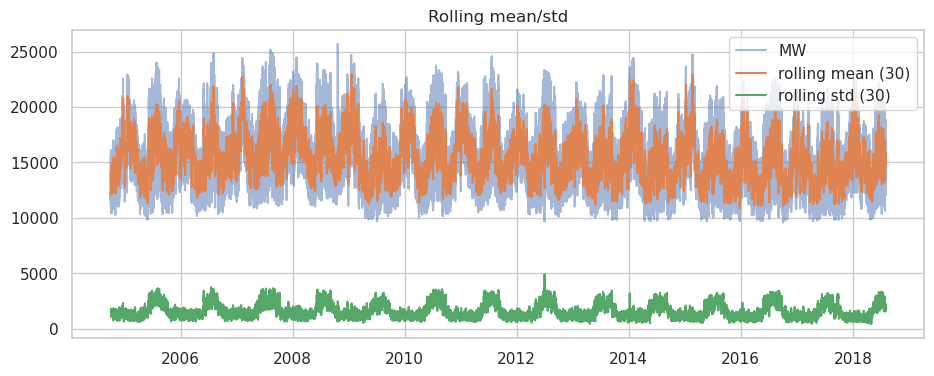

In [14]:
# ACTION: overlay rolling mean/std on the raw series.
# WHY: a rolling mean that visibly trends = non-stationary in the mean; a rolling std
# that visibly widens/narrows over time = non-stationary in variance (heteroscedastic) --
# both feed directly into the stationarity decisions in Section 4.
plot_df = df if not SERIES_ID_COL else df[df[SERIES_ID_COL] == df[SERIES_ID_COL].iloc[0]]
roll = plot_df.set_index(DATE_COL)[TARGET]
fig, ax = plt.subplots()
ax.plot(roll.index, roll, label=TARGET, alpha=0.5)
ax.plot(roll.index, roll.rolling(ROLLING_WINDOW).mean(), label=f"rolling mean ({ROLLING_WINDOW})")
ax.plot(roll.index, roll.rolling(ROLLING_WINDOW).std(), label=f"rolling std ({ROLLING_WINDOW})")
ax.legend(); ax.set_title("Rolling mean/std")
plt.show()

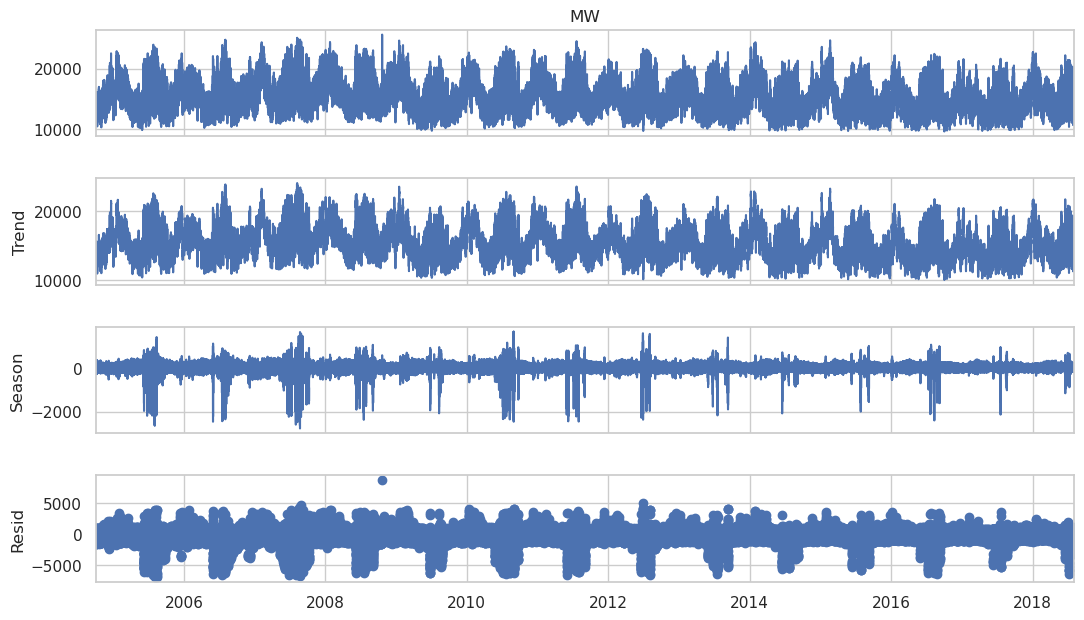

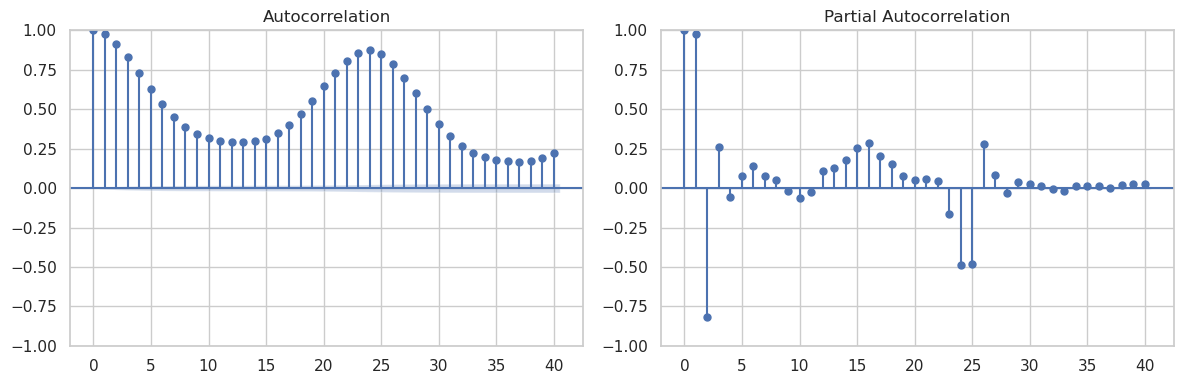

In [15]:

from statsmodels.tsa.seasonal import STL
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
# ACTION: STL decomposition into trend / seasonal / residual components.
# WHY STL over classic seasonal_decompose: STL handles changing seasonal amplitude and
# is robust to outliers; classic decompose assumes a fixed seasonal pattern throughout.
SEASONAL_PERIODS = 7   # <- set explicitly: periods per seasonal cycle (7=weekly on daily
                        #    data, 12=yearly on monthly data, 24=daily on hourly data, ...)

series_for_decomp = roll.asfreq(FREQ).interpolate()  # STL needs no gaps
stl = STL(series_for_decomp, period=SEASONAL_PERIODS, robust=True).fit()
fig = stl.plot()
fig.set_size_inches(11, 7)
plt.show()
# DECISION: trend component sloping -> non-stationary in mean, needs differencing.
# Seasonal component with a clear repeating shape -> the SARIMA seasonal order and
# Fourier terms in Sections 5/7 need SEASONAL_PERIODS set to match. Residual component
# that still shows visible pattern (not just noise) -> the current period isn't
# capturing everything; look for a second seasonal cycle or a missing regressor.
     

# ACTION: ACF and PACF plots on the (still possibly non-stationary) series.
# WHY: ACF tapering off slowly -> trend present, needs differencing. Sharp cutoffs at
# specific lags in PACF -> candidate AR order; in ACF -> candidate MA order. This is the
# classic Box-Jenkins order-identification step, refined further once differenced in Section 4.
max_lags = min(40, len(series_for_decomp) // 2 - 1)
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
plot_acf(series_for_decomp, lags=max_lags, ax=axes[0])
plot_pacf(series_for_decomp, lags=max_lags, ax=axes[1], method="ywm")
plt.tight_layout(); plt.show()

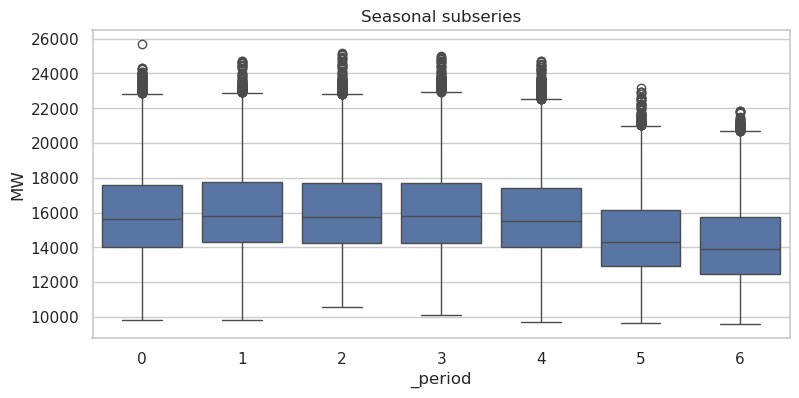

In [16]:
# ACTION: boxplot TARGET grouped by calendar period to confirm the seasonal shape visually.
tmp = plot_df.copy()
tmp["_period"] = tmp[DATE_COL].dt.dayofweek if SEASONAL_PERIODS == 7 else tmp[DATE_COL].dt.month
plt.figure(figsize=(9, 4))
sns.boxplot(data=tmp, x="_period", y=TARGET)
plt.title("Seasonal subseries")
plt.show()

In [17]:
# ACTION: run both tests -- they have OPPOSITE null hypotheses, so agreement between
# them is a much stronger signal than either alone.

from statsmodels.tsa.stattools import adfuller, kpss
def stationarity_report(series, label):
    adf_stat, adf_p, *_ = adfuller(series.dropna())
    kpss_stat, kpss_p, *_ = kpss(series.dropna(), regression="c", nlags="auto")
    print(f"--- {label} ---")
    print(f"ADF:  p={adf_p:.4f}  (H0: unit root / non-stationary -> p<0.05 rejects H0 -> stationary)")
    print(f"KPSS: p={kpss_p:.4f}  (H0: stationary -> p<0.05 rejects H0 -> non-stationary)")
    if adf_p < 0.05 and kpss_p >= 0.05:
        print("-> Both agree: STATIONARY")
    elif adf_p >= 0.05 and kpss_p < 0.05:
        print("-> Both agree: NON-STATIONARY -> differencing needed")
    else:
        print("-> Tests disagree -> borderline/trend-stationary; inspect the plots, lean toward differencing if unsure")

stationarity_report(series_for_decomp, "Original series")

--- Original series ---
ADF:  p=0.0000  (H0: unit root / non-stationary -> p<0.05 rejects H0 -> stationary)
KPSS: p=0.0100  (H0: stationary -> p<0.05 rejects H0 -> non-stationary)
-> Tests disagree -> borderline/trend-stationary; inspect the plots, lean toward differencing if unsure


/tmp/ipykernel_271/2348306418.py:7: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is smaller than the p-value returned.

  kpss_stat, kpss_p, *_ = kpss(series.dropna(), regression="c", nlags="auto")


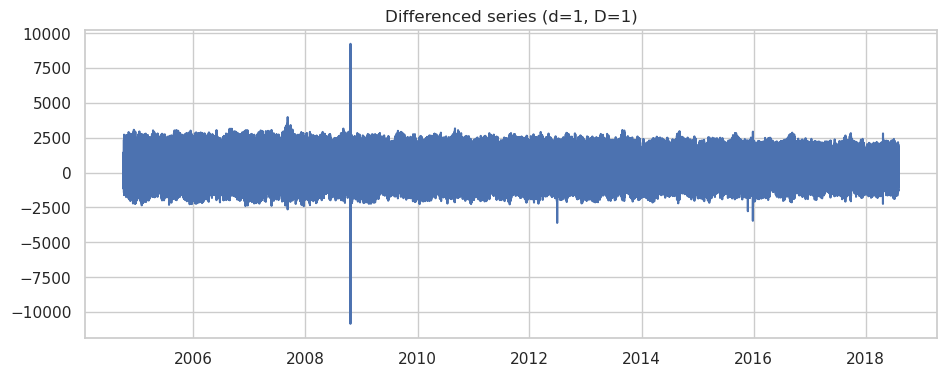

--- Differenced (d=1, D=1) ---
ADF:  p=0.0000  (H0: unit root / non-stationary -> p<0.05 rejects H0 -> stationary)
KPSS: p=0.1000  (H0: stationary -> p<0.05 rejects H0 -> non-stationary)
-> Both agree: STATIONARY


/tmp/ipykernel_271/2348306418.py:7: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is greater than the p-value returned.

  kpss_stat, kpss_p, *_ = kpss(series.dropna(), regression="c", nlags="auto")


In [18]:
# ACTION: apply first differencing (and seasonal differencing if Section 3's
# decomposition showed a clear seasonal component), then re-test.
D_ORDER = 1                                            # <- set explicitly based on the verdict above (0 if already stationary)
SEASONAL_D_ORDER = 1 if SEASONAL_PERIODS > 1 else 0     # <- set explicitly

differenced = series_for_decomp.copy()
if D_ORDER:
    differenced = differenced.diff(D_ORDER)
if SEASONAL_D_ORDER:
    differenced = differenced.diff(SEASONAL_PERIODS)
differenced = differenced.dropna()

plt.plot(differenced.index, differenced); plt.title(f"Differenced series (d={D_ORDER}, D={SEASONAL_D_ORDER})"); plt.show()
stationarity_report(differenced, f"Differenced (d={D_ORDER}, D={SEASONAL_D_ORDER})")
# DECISION: these d/D values feed directly into the SARIMA order in Section 7 -- note
# them down. Over-differencing (d>2 or D>1) usually introduces artificial negative
# autocorrelation -> if still non-stationary at d=2, look for a structural break
# instead of differencing further.

#### Chronological Train/Test Split

Train: (1080268, 31) (1998-05-01 01:00:00 -> 2018-08-01 18:00:00)
Test:  (360, 31) (2001-12-30 19:00:00 -> 2018-08-03 00:00:00)


Built 3 walk-forward folds across 12 regions


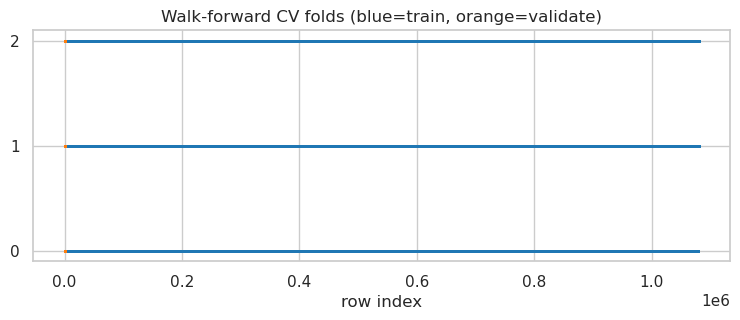

In [19]:
# --- Chronological Train/Test Split (final holdout) ---
# Long-format data: one row per (region, timestamp). Split each region on its
# own last N_TEST_PERIODS rows so the holdout is genuinely "the future" for
# every region, never a mix of one region's past with another's future.
SERIES_ID = SERIES_ID_COL
df_feat = df.copy()
df_feat = df_feat.sort_values([SERIES_ID, DATE_COL]).reset_index(drop=True)
lag_cols = [c for c in df_feat.columns if c.startswith("load_lag_")]
df_feat = df_feat.dropna(subset=lag_cols).reset_index(drop=True)

# Encode region -> integer code ONCE, here, so every downstream frame
# (train_df, test_df, and the CV folds below) already has a numeric column
# and tree models don't choke on a string column later.
region_codes = sorted(df_feat[SERIES_ID].unique())
region_code_map = {r: i for i, r in enumerate(region_codes)}
df_feat[SERIES_ID] = df_feat[SERIES_ID].map(region_code_map)

def chrono_split(g):
    return g.iloc[:-N_TEST_PERIODS], g.iloc[-N_TEST_PERIODS:]

train_parts, test_parts = [], []
for _, g in df_feat.groupby(SERIES_ID, sort=False):
    tr, te = chrono_split(g)
    if len(tr) >= N_TEST_PERIODS:
        train_parts.append(tr); test_parts.append(te)
train_df = pd.concat(train_parts).reset_index(drop=True)
test_df  = pd.concat(test_parts).reset_index(drop=True)

print(f"Train: {train_df.shape} ({train_df[DATE_COL].min()} -> {train_df[DATE_COL].max()})")
print(f"Test:  {test_df.shape} ({test_df[DATE_COL].min()} -> {test_df[DATE_COL].max()})")

# --- Walk-forward CV folds ---
# FIX: build folds per region (each region's own TimeSeriesSplit, so cuts are
# always chronological within that region), then combine matching fold
# numbers across regions. This keeps two things true at once:
#   - global models (Random Forest / XGBoost / LightGBM, trained once per
#     fold on every region at once) still get multi-region training data
#   - per-region models (SARIMA, Holt-Winters, naive, LSTM) can safely
#     assume every row they see belongs to one uninterrupted timeline
tscv = TimeSeriesSplit(n_splits=N_SPLITS, test_size=N_TEST_PERIODS)

fold_train_parts = [[] for _ in range(N_SPLITS)]
fold_val_parts   = [[] for _ in range(N_SPLITS)]
for region, g in df_feat.groupby(SERIES_ID, sort=False):
    g = g.reset_index(drop=True)
    if len(g) <= N_TEST_PERIODS * N_SPLITS:
        continue  # not enough history for this many folds
    for k, (tr_idx, val_idx) in enumerate(tscv.split(g)):
        fold_train_parts[k].append(g.iloc[tr_idx])
        fold_val_parts[k].append(g.iloc[val_idx])

folds = [
    (pd.concat(fold_train_parts[k]).reset_index(drop=True),
     pd.concat(fold_val_parts[k]).reset_index(drop=True))
    for k in range(N_SPLITS)
]
print(f"Built {len(folds)} walk-forward folds across {df_feat[SERIES_ID].nunique()} regions")

fig, ax = plt.subplots(figsize=(9, 3))
for k, (tr, val) in enumerate(folds):
    ax.scatter(tr.index, [k]*len(tr), c="tab:blue", s=1)
    ax.scatter(val.index, [k]*len(val), c="tab:orange", s=1)
ax.set_title("Walk-forward CV folds (blue=train, orange=validate)")
ax.set_xlabel("row index"); ax.set_yticks(range(N_SPLITS))
plt.show()


### Model Building


In [20]:
# Shared walk-forward evaluation helper, reused by every model below.
results = {}

def evaluate_forecast(name, forecast_fn):
    """forecast_fn(train_slice, val_slice) -> predictions aligned to val_slice."""
    scores = {"MAE": [], "RMSE": [], "sMAPE": []}
    for tr, val in folds:
        try:
            preds = forecast_fn(tr, val)
        except Exception as e:
            print(f"  {name}: fold failed ({e})")
            continue
        y_true_fold = val[TARGET].values
        scores["MAE"].append(mean_absolute_error(y_true_fold, preds))
        scores["RMSE"].append(np.sqrt(mean_squared_error(y_true_fold, preds)))
        scores["sMAPE"].append(smape(y_true_fold, preds))
    summary = {k: np.mean(v) if v else np.nan for k, v in scores.items()}
    results[name] = summary
    print(f"{name}: MAE={summary['MAE']:.3f}  RMSE={summary['RMSE']:.3f}  sMAPE={summary['sMAPE']:.2f}%")
    return summary

def per_region(single_series_fn):
    """Wrap a forecast_fn(tr_one_region, val_one_region) so it can be called on
    multi-region tr/val slices: forecasts each region separately, then
    reassembles predictions in val's original row order. Every classical /
    DL model below needs this -- they all assume one continuous timeline,
    same as SARIMA already did in the original notebook."""
    def wrapped(tr, val):
        preds = []
        for region, g_val in val.groupby(SERIES_ID_COL, sort=False):
            g_tr = tr[tr[SERIES_ID_COL] == region]
            if len(g_tr) == 0:
                preds.append(np.full(len(g_val), np.nan)); continue
            try:
                preds.append(single_series_fn(g_tr, g_val))
            except Exception as e:
                print(f"    {single_series_fn.__name__} [region {region}]: failed ({e})")
                preds.append(np.full(len(g_val), np.nan))
        return np.concatenate(preds)
    wrapped.__name__ = single_series_fn.__name__
    return wrapped


In [21]:
@per_region
def naive_forecast(tr, val):
    return np.repeat(tr[TARGET].iloc[-1], len(val))

@per_region
def seasonal_naive_forecast(tr, val):
    last_cycle = tr[TARGET].iloc[-SEASONAL_PERIODS:].values
    reps = int(np.ceil(len(val) / SEASONAL_PERIODS))
    return np.tile(last_cycle, reps)[:len(val)]

evaluate_forecast("Naive (last value)", naive_forecast)
evaluate_forecast("Seasonal Naive", seasonal_naive_forecast)


Naive (last value): MAE=1844.955  RMSE=3068.163  sMAPE=16.21%
Seasonal Naive: MAE=1950.444  RMSE=3245.807  sMAPE=17.26%


{'MAE': np.float64(1950.4444444444446),
 'RMSE': np.float64(3245.80715883325),
 'sMAPE': np.float64(17.25649307919614)}

In [22]:
@per_region
def holt_winters_forecast(tr, val):
    model = ExponentialSmoothing(
        tr[TARGET], trend="add", seasonal="add", seasonal_periods=SEASONAL_PERIODS,
        initialization_method="estimated",
    ).fit()
    return model.forecast(len(val)).values

evaluate_forecast("Holt-Winters", holt_winters_forecast)


/opt/conda/lib/python3.12/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: An unsupported index was provided. As a result, forecasts cannot be generated. To use the model for forecasting, use one of the supported classes of index.
  self._init_dates(dates, freq)


/opt/conda/lib/python3.12/site-packages/statsmodels/tsa/base/tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(


/opt/conda/lib/python3.12/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: An unsupported index was provided. As a result, forecasts cannot be generated. To use the model for forecasting, use one of the supported classes of index.
  self._init_dates(dates, freq)


/opt/conda/lib/python3.12/site-packages/statsmodels/tsa/base/tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(


/opt/conda/lib/python3.12/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: An unsupported index was provided. As a result, forecasts cannot be generated. To use the model for forecasting, use one of the supported classes of index.
  self._init_dates(dates, freq)


...

/opt/conda/lib/python3.12/site-packages/statsmodels/tsa/base/tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(


/opt/conda/lib/python3.12/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: An unsupported index was provided. As a result, forecasts cannot be generated. To use the model for forecasting, use one of the supported classes of index.
  self._init_dates(dates, freq)


/opt/conda/lib/python3.12/site-packages/statsmodels/tsa/base/tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(


Holt-Winters: MAE=6383.617  RMSE=13638.018  sMAPE=34.92%


{'MAE': np.float64(6383.6170026952495),
 'RMSE': np.float64(13638.018484142303),
 'sMAPE': np.float64(34.91801539464081)}

In [ ]:
# SARIMA(p,d,q)(P,D,Q,s)
# Capped to the most recent MAX_TRAIN_POINTS per region: a couple of years of
# hourly data is plenty for SARIMA to learn the seasonal pattern, and it
# keeps memory/runtime bounded regardless of how much history a region has.
SARIMA_ORDER = (1, D_ORDER, 1)
SARIMA_SEASONAL_ORDER = (1, SEASONAL_D_ORDER, 1, SEASONAL_PERIODS)

@per_region
def sarima_forecast(tr, val):
    s = tr[TARGET].dropna().tail(MAX_TRAIN_POINTS)
    model = SARIMAX(s, order=SARIMA_ORDER, seasonal_order=SARIMA_SEASONAL_ORDER,
                     enforce_stationarity=False, enforce_invertibility=False).fit(disp=False)
    return model.forecast(len(val)).values

evaluate_forecast("SARIMA (manual order, per-region)", sarima_forecast)

# auto_arima on one representative region, just to sanity-check the manual
# order above -- running it per-region x per-fold would be very slow.
if HAVE_PMDARIMA:
    _sample = train_df[train_df[SERIES_ID_COL] == train_df[SERIES_ID_COL].iloc[0]]
    _sample = _sample[TARGET].dropna().tail(MAX_TRAIN_POINTS)
    auto_model = auto_arima(_sample, seasonal=True, m=SEASONAL_PERIODS,
                             d=D_ORDER, D=SEASONAL_D_ORDER, trace=False,
                             error_action="ignore", suppress_warnings=True)
    print(f"auto_arima best order (first region): {auto_model.order} seasonal_order: {auto_model.seasonal_order}")
else:
    print("Skipping auto_arima (pmdarima not installed).")


/opt/conda/lib/python3.12/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: An unsupported index was provided. As a result, forecasts cannot be generated. To use the model for forecasting, use one of the supported classes of index.
  self._init_dates(dates, freq)
/opt/conda/lib/python3.12/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: An unsupported index was provided. As a result, forecasts cannot be generated. To use the model for forecasting, use one of the supported classes of index.
  self._init_dates(dates, freq)


/opt/conda/lib/python3.12/site-packages/statsmodels/tsa/base/tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(
/opt/conda/lib/python3.12/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: An unsupported index was provided. As a result, forecasts cannot be generated. To use the model for forecasting, use one of the supported classes of index.
  self._init_dates(dates, freq)
/opt/conda/lib/python3.12/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: An unsupported index was provided. As a result, forecasts cannot be generated. To use the model for forecasting, use one of the supported classes of index.
  self._init_dates(dates, freq)


/opt/conda/lib/python3.12/site-packages/statsmodels/tsa/base/tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(
/opt/conda/lib/python3.12/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: An unsupported index was provided. As a result, forecasts cannot be generated. To use the model for forecasting, use one of the supported classes of index.
  self._init_dates(dates, freq)
/opt/conda/lib/python3.12/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: An unsupported index was provided. As a result, forecasts cannot be generated. To use the model for forecasting, use one of the supported classes of index.
  self._init_dates(dates, freq)


/opt/conda/lib/python3.12/site-packages/statsmodels/tsa/base/tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(
/opt/conda/lib/python3.12/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: An unsupported index was provided. As a result, forecasts cannot be generated. To use the model for forecasting, use one of the supported classes of index.
  self._init_dates(dates, freq)
/opt/conda/lib/python3.12/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: An unsupported index was provided. As a result, forecasts cannot be generated. To use the model for forecasting, use one of the supported classes of index.
  self._init_dates(dates, freq)


/opt/conda/lib/python3.12/site-packages/statsmodels/tsa/base/tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(
/opt/conda/lib/python3.12/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: An unsupported index was provided. As a result, forecasts cannot be generated. To use the model for forecasting, use one of the supported classes of index.
  self._init_dates(dates, freq)
/opt/conda/lib/python3.12/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: An unsupported index was provided. As a result, forecasts cannot be generated. To use the model for forecasting, use one of the supported classes of index.
  self._init_dates(dates, freq)


...

/opt/conda/lib/python3.12/site-packages/statsmodels/tsa/base/tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(
/opt/conda/lib/python3.12/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: An unsupported index was provided. As a result, forecasts cannot be generated. To use the model for forecasting, use one of the supported classes of index.
  self._init_dates(dates, freq)
/opt/conda/lib/python3.12/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: An unsupported index was provided. As a result, forecasts cannot be generated. To use the model for forecasting, use one of the supported classes of index.
  self._init_dates(dates, freq)


/opt/conda/lib/python3.12/site-packages/statsmodels/tsa/base/tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(
/opt/conda/lib/python3.12/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: An unsupported index was provided. As a result, forecasts cannot be generated. To use the model for forecasting, use one of the supported classes of index.
  self._init_dates(dates, freq)
/opt/conda/lib/python3.12/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: An unsupported index was provided. As a result, forecasts cannot be generated. To use the model for forecasting, use one of the supported classes of index.
  self._init_dates(dates, freq)


/opt/conda/lib/python3.12/site-packages/statsmodels/tsa/base/tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(
/opt/conda/lib/python3.12/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: An unsupported index was provided. As a result, forecasts cannot be generated. To use the model for forecasting, use one of the supported classes of index.
  self._init_dates(dates, freq)
/opt/conda/lib/python3.12/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: An unsupported index was provided. As a result, forecasts cannot be generated. To use the model for forecasting, use one of the supported classes of index.
  self._init_dates(dates, freq)


/opt/conda/lib/python3.12/site-packages/statsmodels/tsa/base/tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(


SARIMA (manual order, per-region): MAE=1907.861  RMSE=3186.447  sMAPE=15.21%


In [ ]:
if HAVE_PROPHET:
    @per_region
    def prophet_forecast(tr, val):
        p_df = tr[[DATE_COL, TARGET]].rename(columns={DATE_COL: "ds", TARGET: "y"})
        model = Prophet()
        for c in EXOG_COLS:
            if c in tr.columns:
                model.add_regressor(c)
                p_df[c] = tr[c].values
        model.fit(p_df)
        future_cols = [DATE_COL] + [c for c in EXOG_COLS if c in val.columns]
        future = val[future_cols].rename(columns={DATE_COL: "ds"})
        return model.predict(future)["yhat"].values

    evaluate_forecast("Prophet", prophet_forecast)
else:
    print("Skipping Prophet (not installed).")


In [ ]:
FEATURE_COLS = [c for c in df_feat.columns if c not in [DATE_COL, TARGET, SERIES_ID_COL, "_is_outlier"]]
if SERIES_ID_COL:
    FEATURE_COLS = FEATURE_COLS + [SERIES_ID_COL]

# Cap the final holdout train/test sets to the most recent MAX_TRAIN_POINTS
# per region too, so this section's memory/runtime stays bounded the same
# way the CV folds and SARIMA already are.
def _cap_recent(g):
    return g.tail(MAX_TRAIN_POINTS)
train_df = train_df.groupby(SERIES_ID_COL, sort=False, group_keys=False).apply(_cap_recent).reset_index(drop=True)
test_df  = test_df.groupby(SERIES_ID_COL, sort=False, group_keys=False).apply(_cap_recent).reset_index(drop=True)
print(f"ML after cap: train_df {train_df.shape}, test_df {test_df.shape}")

def ml_forecast(model_class, **kwargs):
    # Trained ONCE per fold on every region at once (region is just a feature) --
    # unlike the models above, these don't need the per_region wrapper.
    def _forecast(tr, val):
        model = model_class(**kwargs)
        model.fit(tr[FEATURE_COLS], tr[TARGET])
        return model.predict(val[FEATURE_COLS])
    return _forecast

evaluate_forecast("Random Forest (lag features)", ml_forecast(RandomForestRegressor, n_estimators=300, random_state=RANDOM_STATE, n_jobs=-1))
evaluate_forecast("XGBoost (lag features)", ml_forecast(xgb.XGBRegressor, random_state=RANDOM_STATE, n_jobs=-1))
evaluate_forecast("LightGBM (lag features)", ml_forecast(lgb.LGBMRegressor, random_state=RANDOM_STATE, n_jobs=-1, verbose=-1))


In [ ]:
if HAVE_TENSORFLOW:
    LOOKBACK = SEASONAL_PERIODS * 2   # how many past periods the LSTM sees per prediction

    def make_sequences(values, lookback):
        X, y = [], []
        for i in range(lookback, len(values)):
            X.append(values[i - lookback:i])
            y.append(values[i])
        return np.array(X), np.array(y)

    @per_region
    def lstm_forecast(tr, val):
        scaler = StandardScaler()
        tr_scaled = scaler.fit_transform(tr[[TARGET]]).flatten()
        X_tr, y_tr = make_sequences(tr_scaled, LOOKBACK)
        X_tr = X_tr.reshape(-1, LOOKBACK, 1)

        model = Sequential([LSTM(32, input_shape=(LOOKBACK, 1)), Dense(1)])
        model.compile(optimizer="adam", loss="mse")
        model.fit(X_tr, y_tr, epochs=30, batch_size=32, verbose=0,
                  callbacks=[EarlyStopping(patience=5, restore_best_weights=True)],
                  validation_split=0.1)

        window = tr_scaled[-LOOKBACK:].tolist()
        preds_scaled = []
        for _ in range(len(val)):
            x = np.array(window[-LOOKBACK:]).reshape(1, LOOKBACK, 1)
            p = model.predict(x, verbose=0)[0, 0]
            preds_scaled.append(p)
            window.append(p)
        return scaler.inverse_transform(np.array(preds_scaled).reshape(-1, 1)).flatten()

    # NOTE on cost: this now correctly trains one small LSTM per region per fold
    # (12 regions x N_SPLITS folds). That's the most expensive cell in the
    # notebook. To cut runtime further without touching the code above:
    #   - lower N_SPLITS in the config cell (3 -> 2 folds = 1/3 less LSTM work)
    #   - lower epochs (30 -> 15) or batch_size up (32 -> 64)
    #   - temporarily test on a subset: evaluate_forecast("LSTM", lstm_forecast)
    #     but pass folds built from df_feat[df_feat[SERIES_ID_COL].isin([0,1,2])]
    evaluate_forecast("LSTM", lstm_forecast)
else:
    print("Skipping LSTM (tensorflow not installed).")


In [ ]:
summary_df = pd.DataFrame(results).T.sort_values("sMAPE")
print(summary_df)
summary_df["sMAPE"].plot(kind="barh", title="Model comparison (sMAPE, lower is better)")
plt.gca().invert_yaxis(); plt.show()
